In [117]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [118]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Booth_helpers import *
from utils.Phase_diversity_helpers_cupy import *

In [119]:
#minor style things to make the figures look nice
#plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 15
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [127]:
N_order = 3              # 3 for 3P, 2 for 2P
lambd = 1.3e-3            # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05            # Numerical aperture
focal = 7.2                    # Focal length of objective (Olympus) [mm]
mag = 4                   # Magnification rate from input to objective
w_0 = 3.5                 # mm
alpha = np.arcsin(num_apt / n)

#50 microns
L_ffp = 0.025
#512 x 512
grid_ffp = 256
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
#CONJUGATE BFP LENGTH
grid_bfp = grid_ffp
L_bfp = (lambd * focal * grid_bfp) / L_ffp
microscope = Microscope(N_order, lambd, n, num_apt, focal, mag, w_0, L_bfp, grid_bfp)
x, y = grid.get_xy()
x_bfp = x * (L_bfp/ L_ffp)
y_bfp = y * (L_bfp/ L_ffp)

In [128]:
from pathlib import Path
import numpy as np
import scipy.io as sio
import tifffile


def _mat_to_python(obj):
    """
    Recursively convert scipy.io.loadmat MATLAB structs/cells
    into Python dicts/lists/arrays where possible.
    """
    if isinstance(obj, np.ndarray):
        # MATLAB struct array
        if obj.dtype.names is not None:
            return [_mat_to_python(x) for x in obj.flat]

        # MATLAB cell array or object array
        if obj.dtype == object:
            return [_mat_to_python(x) for x in obj.flat]

        # Numeric/logical array
        return obj

    # MATLAB struct scalar
    if hasattr(obj, "_fieldnames"):
        return {
            field: _mat_to_python(getattr(obj, field))
            for field in obj._fieldnames
        }

    return obj


def _as_string(x):
    """
    Clean up strings loaded from MATLAB.
    """
    if isinstance(x, str):
        return x

    if isinstance(x, np.ndarray):
        if x.dtype.kind in {"U", "S"}:
            return "".join(x.ravel().astype(str)).strip()

        if x.size == 1:
            return _as_string(x.item())

    return str(x)


def _as_column_array(x):
    """
    Convert MATLAB-loaded values into a clean 1D numpy array.
    """
    x = np.asarray(x)
    return np.squeeze(x)


def load_phase_diversity_output(output_folder):
    """
    Load images and metadata produced by grab_data.m.

    Parameters
    ----------
    output_folder : str or pathlib.Path
        Folder containing Img_*.tif and aberration_series_log.mat.

    Returns
    -------
    data : dict
        Dictionary with fields:

        images : ndarray, shape (N, H, W)
            Image stack in acquisition/log order.

        names : list[str]
            Aberration names, e.g. ['flat', 'astig_3_plus', ...].

        filenames : list[str]
            TIFF filenames corresponding to images.

        nm : list[ndarray]
            Zernike [n, m] arrays for each image.

        coeffs : list[ndarray]
            Zernike coefficients in waves for each image.

        phase_waves : list[ndarray]
            Vectorized SLM phase maps in waves.

        pupil : list[ndarray]
            Vectorized pupil masks.

        mat : dict
            Full loaded MATLAB log dictionary.

        underlying_nm : ndarray
            Underlying aberration Zernike modes.

        underlying_coeffs : ndarray
            Underlying aberration coefficients in waves.

        underlyingRMSWaves : float
            Desired underlying RMS in waves.
    """
    output_folder = Path(output_folder)

    mat_path = output_folder / "aberration_series_log.mat"
    if not mat_path.exists():
        raise FileNotFoundError(f"Could not find {mat_path}")

    mat_raw = sio.loadmat(
        mat_path,
        squeeze_me=True,
        struct_as_record=False
    )

    mat = {
        k: _mat_to_python(v)
        for k, v in mat_raw.items()
        if not k.startswith("__")
    }

    log = mat["log"]

    # If there is only one log entry, make it a list.
    if isinstance(log, dict):
        log = [log]

    names = []
    filenames = []
    nm_list = []
    coeffs_list = []
    phase_waves_list = []
    pupil_list = []
    images = []

    for entry in log:
        name = _as_string(entry["name"])
        filename = _as_string(entry["filename"])

        img_path = output_folder / filename
        if not img_path.exists():
            raise FileNotFoundError(f"Missing image file: {img_path}")

        img = tifffile.imread(img_path)

        names.append(name)
        filenames.append(filename)
        nm_list.append(np.asarray(entry["nm"], dtype=int))
        coeffs_list.append(_as_column_array(entry["coeffs"]).astype(float))
        phase_waves_list.append(_as_column_array(entry["phase_waves"]).astype(float))
        pupil_list.append(_as_column_array(entry["pupil"]).astype(bool))
        images.append(img.astype(float))

    images = np.stack(images, axis=0)

    data = {
        "images": images,
        "names": names,
        "filenames": filenames,
        "nm": nm_list,
        "coeffs": coeffs_list,
        "phase_waves": phase_waves_list,
        "pupil": pupil_list,
        "mat": mat,
        "underlying_nm": np.asarray(mat["underlying_nm"], dtype=int),
        "underlying_coeffs": _as_column_array(mat["underlying_coeffs"]).astype(float),
        "underlyingRMSWaves": float(np.squeeze(mat["underlyingRMSWaves"])),
    }

    return data

In [129]:
def matlab_nm_to_python_modes(nm_matlab):
    """
    Convert MATLAB Zernike convention [n, m]
    into your Python convention [m, n].
    """
    nm_matlab = np.asarray(nm_matlab, dtype=int)

    if nm_matlab.ndim == 1:
        nm_matlab = nm_matlab.reshape(1, 2)

    return nm_matlab[:, [1, 0]]

def make_a_stack_from_data(data, num_underlying_modes=17):
    """
    Construct the known phase-diversity aberration stack.

    Your MATLAB log stores, for each frame:

        nm     = [bias_nm; underlying_nm]
        coeffs = [bias_coeffs; underlying_coeffs]

    For phase-diversity optimization, a_stack should contain only
    the known bias aberration applied to each frame.
    The underlying aberration is the unknown thing being estimated.
    """
    a_stack = []

    for nm_full, coeffs_full in zip(data["nm"], data["coeffs"]):
        nm_full = np.asarray(nm_full, dtype=int)
        coeffs_full = np.asarray(coeffs_full, dtype=float).ravel()

        # Remove the underlying unknown aberration modes from the end
        bias_nm_matlab = nm_full[:-num_underlying_modes]
        bias_coeffs = coeffs_full[:-num_underlying_modes]

        # Convert [n, m] -> [m, n] for your Python Aberration class
        bias_modes_python = matlab_nm_to_python_modes(bias_nm_matlab)

        a_stack.append(Aberration(bias_modes_python, bias_coeffs))

    return a_stack

def jointly_normalize_images(images, eps=1e-15):
    """
    Jointly normalize a stack of images so the global min maps to 0
    and the global max maps to 1.

    images should have shape (N, H, W).
    """
    images = np.asarray(images, dtype=float)

    img_min = np.min(images)
    img_max = np.max(images)

    return (images - img_min) / (img_max - img_min + eps)

In [130]:
data = load_phase_diversity_output("phase_diversity_fluorobead_4_25micron")

# Known phase-diversity aberrations
a_stack = make_a_stack_from_data(data, num_underlying_modes=17)

# Jointly normalized measured images
d_stack = jointly_normalize_images(data["images"])

print("d_stack shape:", d_stack.shape)
print("number of diversity frames:", len(a_stack))

for name, a in zip(data["names"], a_stack):
    print(name, a.modes, a.strengths)

d_stack shape: (7, 256, 256)
number of diversity frames: 7
flat [[2, 2]] [0.0]
astig_3_plus [[2, 2]] [0.25]
astig_5_plus [[-2, 2]] [0.25]
astig_3_minus [[2, 2]] [-0.25]
astig_5_minus [[-2, 2]] [-0.25]
spher_plus [[0, 4]] [0.25]
spher_minus [[0, 4]] [-0.25]


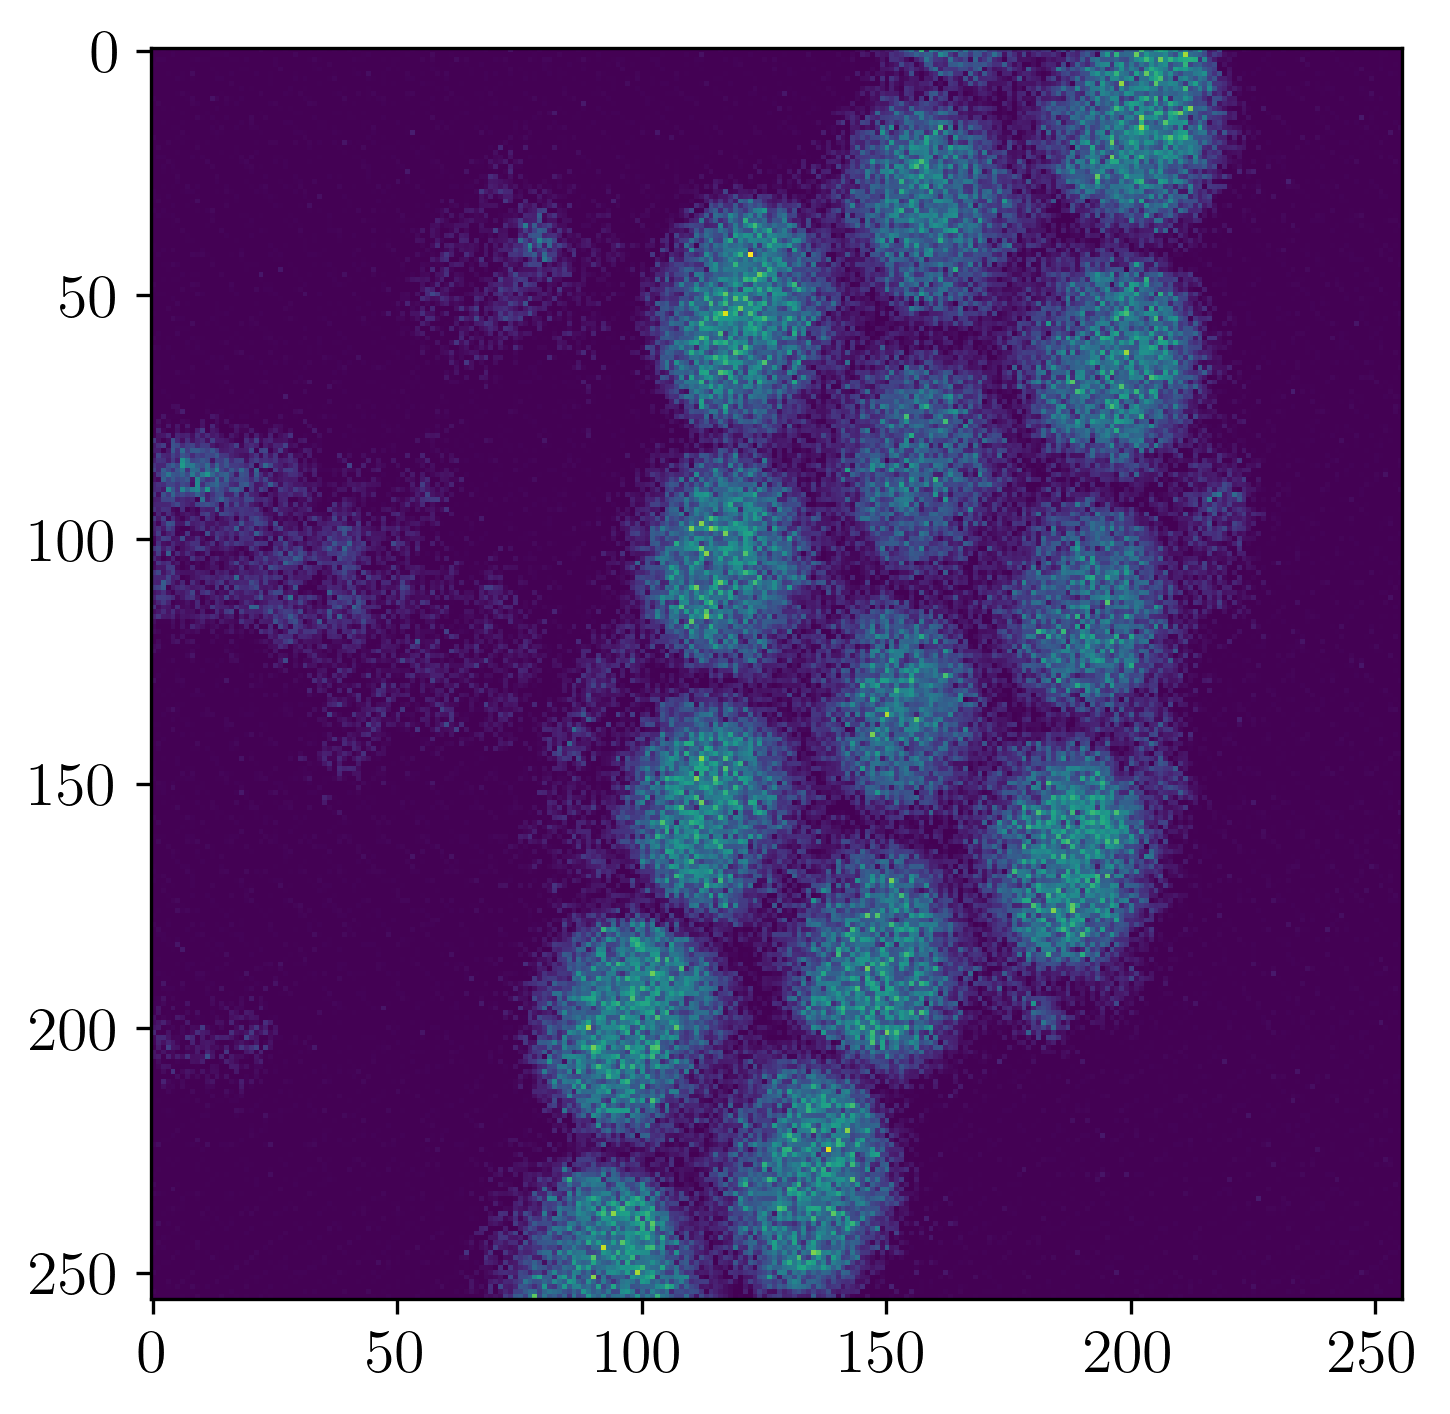

In [131]:
plt.imshow(d_stack[2])

In [132]:
gamma = 1e-24

params = {
                "gamma": gamma,
                "J_tol": 0.001,
                "max_step": 0.05
            }

modes_corrected = get_johnson_modes()


c_guess, F_guess, c_guess_log, F_guess_log, J_log = loop_optimize(
    n_loops=200,
    microscope=microscope,
    d_stack=d_stack,
    a_stack=a_stack,
    modes_corrected=modes_corrected,
    params=params,
    debug=False,
    log=True,
    gaussian=True,
)

 19%|█▉        | 38/200 [00:59<04:12,  1.56s/it]


In [133]:
true_aberration = Aberration(get_johnson_modes(), data["underlying_coeffs"])

In [134]:
max_index = 200
try:
    max_index = np.where(J_log <= 0)[0][0]
except:
    pass
rms_vals = np.zeros(max_index)
for i in range(max_index):
    diff = Aberration(modes_corrected, c_guess_log[i]) - true_aberration
    rms_vals[i] = zernike_RMS(diff, alpha)


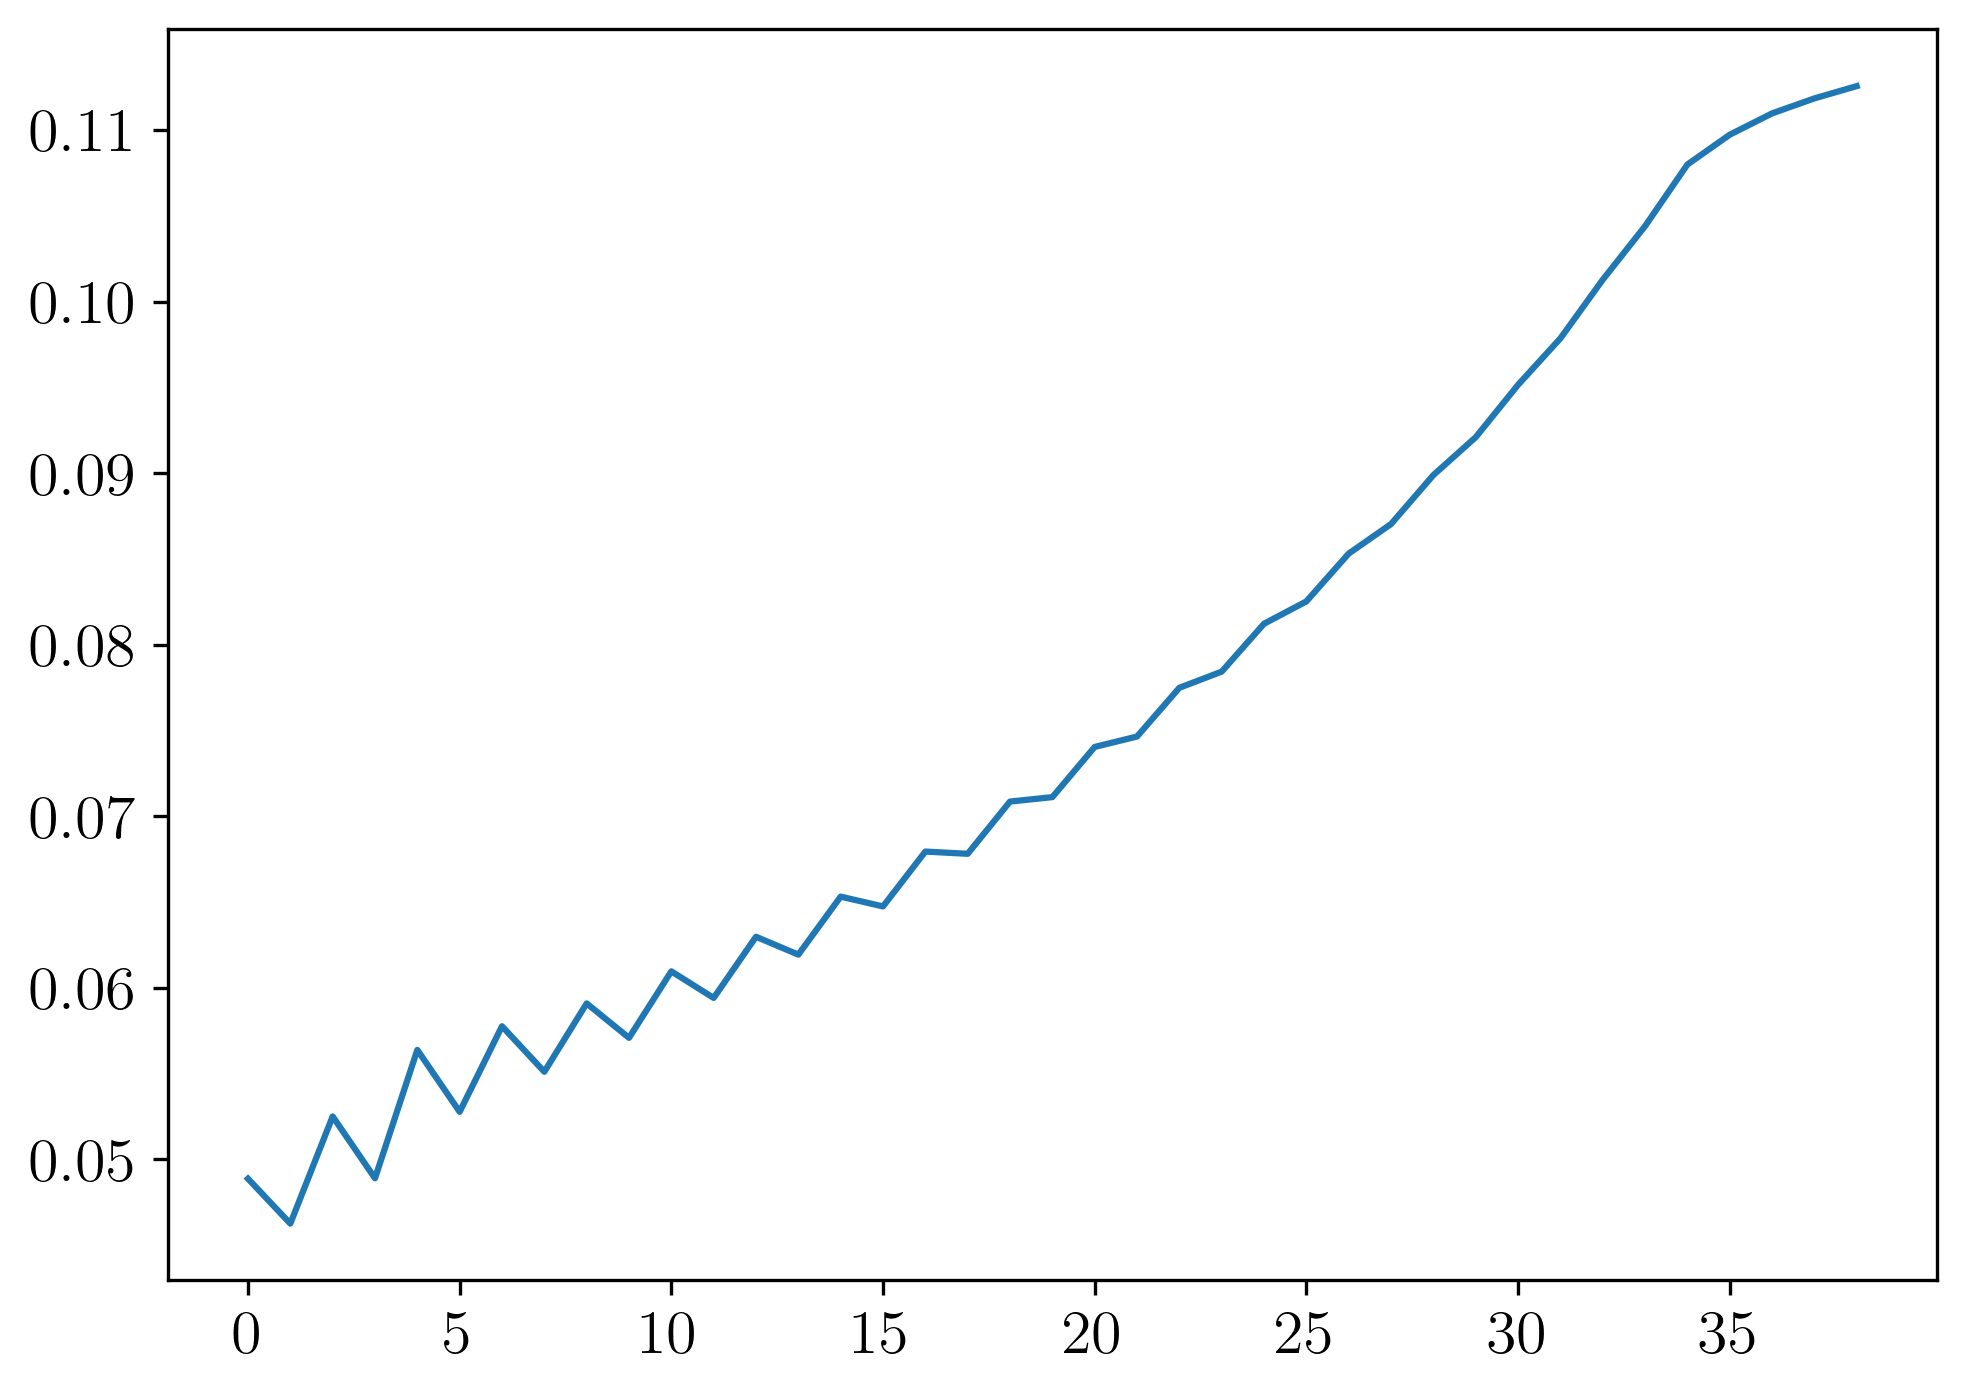

In [135]:
plt.plot(rms_vals)

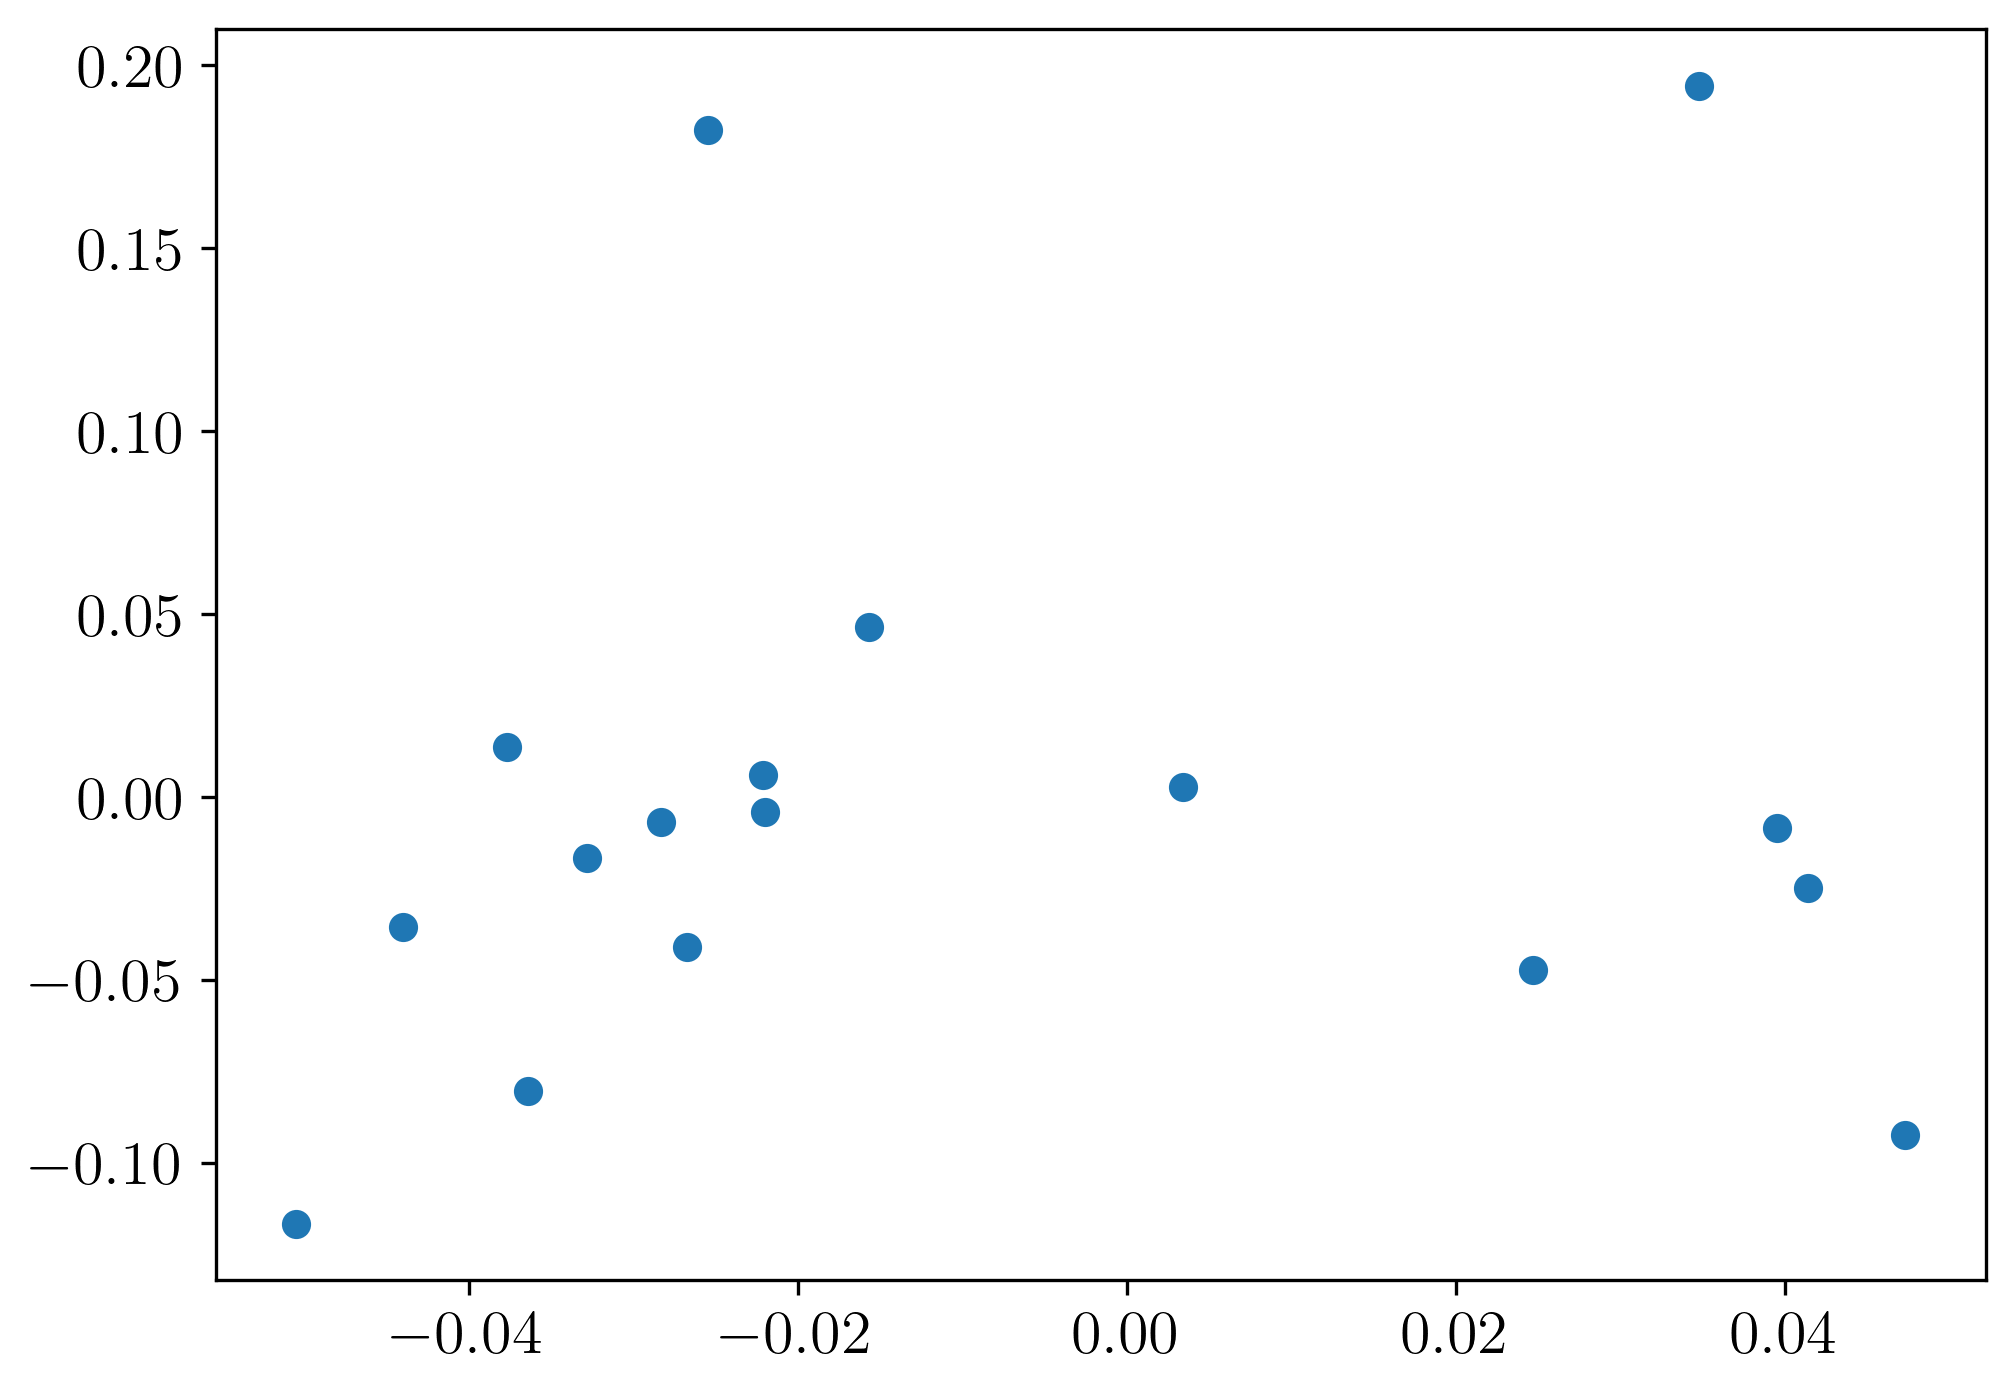

In [136]:
plt.scatter(data["underlying_coeffs"], c_guess)

In [137]:
c_guess

array([-0.00846663, -0.08043547, -0.11654322,  0.04654436,  0.18217984,
        0.00281779, -0.00414381,  0.00598166, -0.035545  , -0.00677295,
       -0.09222291, -0.04106249, -0.04710832, -0.02480264,  0.19430879,
       -0.01668538,  0.01366582])

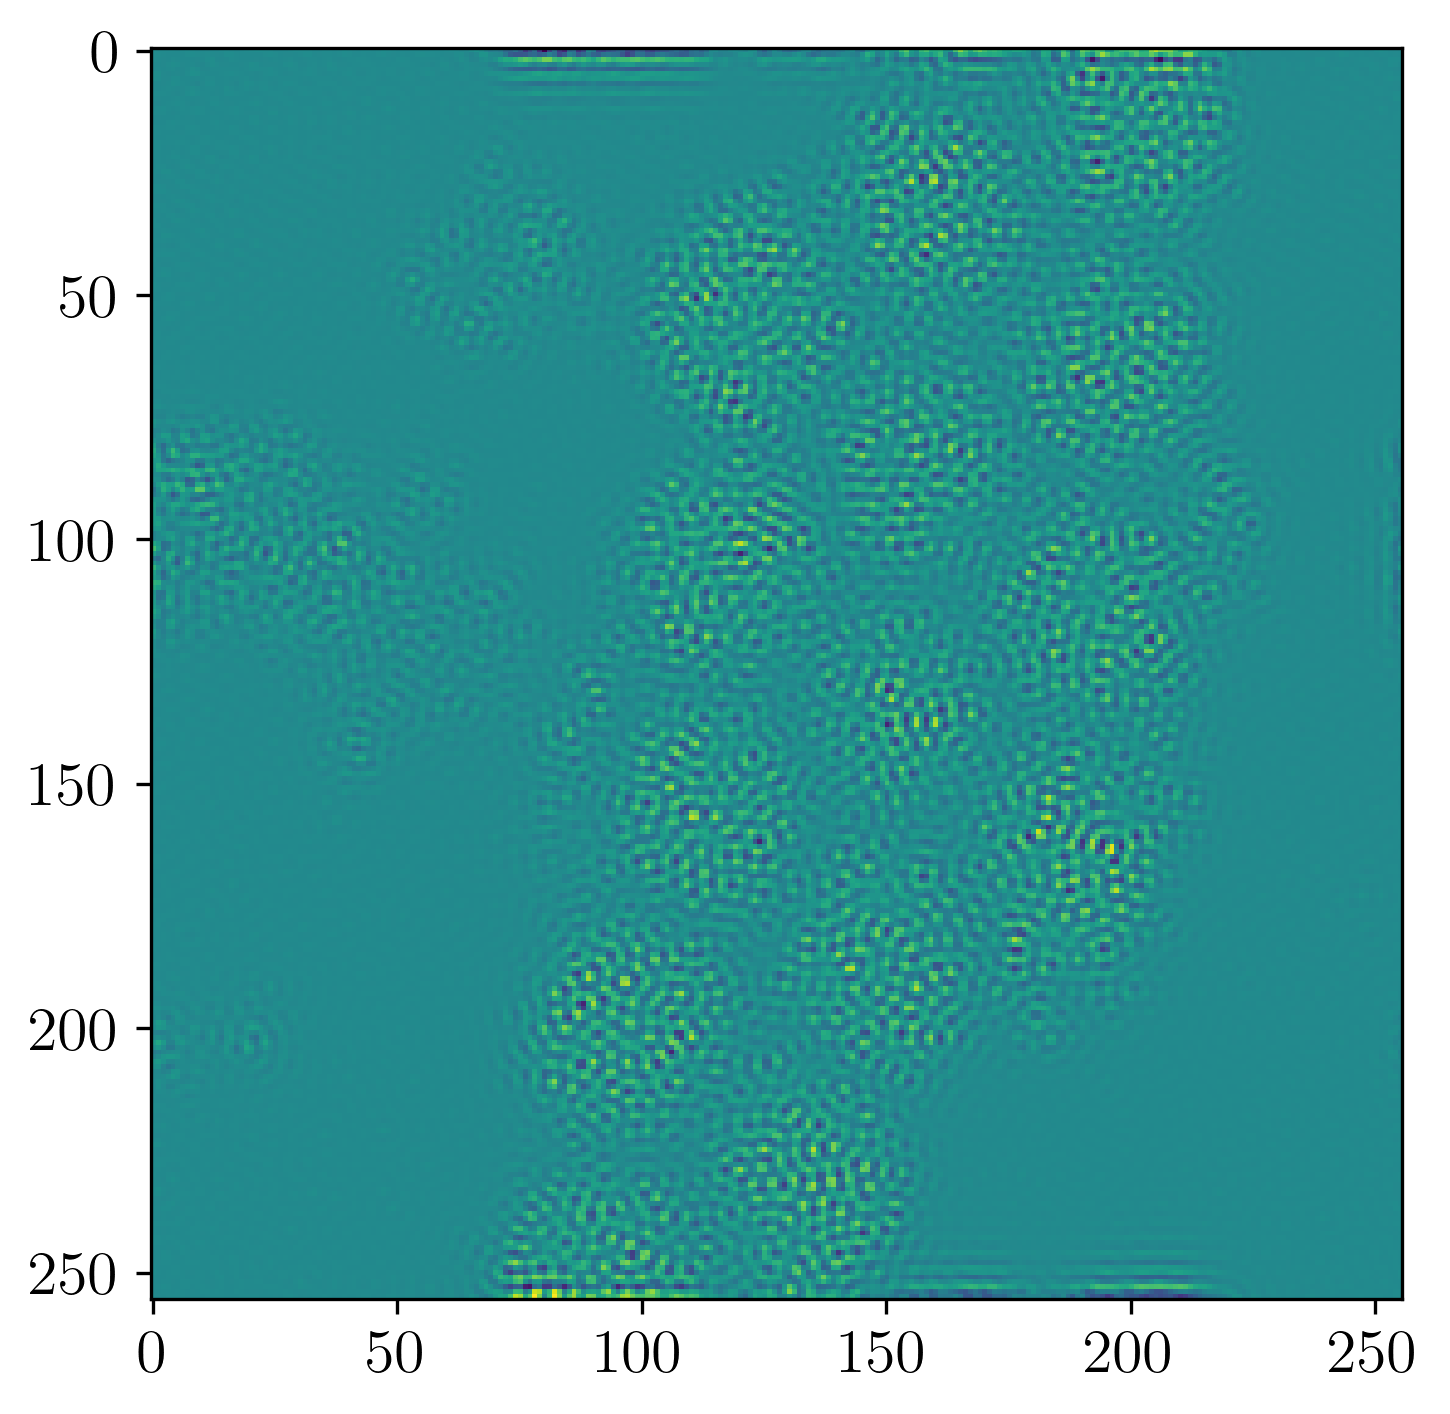

In [141]:
plt.imshow(np.real(np.fft.ifft2(F_guess)))